<a href="https://colab.research.google.com/github/rd-gabriela/IC-percepcao-temporal/blob/main/ModeloContaTiques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

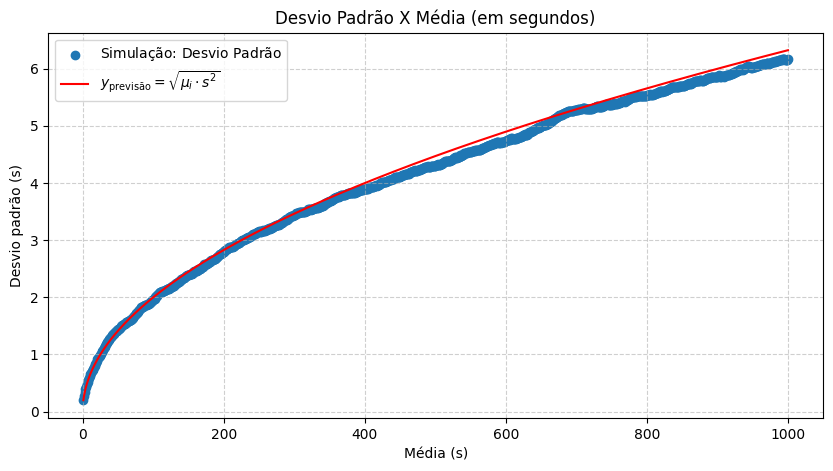

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

#Passo (distância entre "tiques") e distribuição dos erros
h = 1                                            #valores escolhidos inicialmente, pode ser generalizado
media_e = 0
s = 0.2

#Repetições
repeticoes = 1000
t = 1000                                        #t -> numero de intervalos (o tempo alvo é dado pelo acúmulo de 'h's)

#Matriz para armazenar os tiques_n ao longo dos 't' intervalos
matriz = []

for i in range(repeticoes):
  #cria a linha
  linha = []
  #inicia no tique = 0
  tique_n = 0                                                      #tique_n = valor do tique "ideal" + o erro sorteado

  #j fornece as colunas (nesse caso, isso é dado pelo numero de intervalos (t))
  for j in range(t):
    erro = s * np.random.randn() + media_e                      #sorteia um erro da distribuição normal de erros de media_e = 0, s = 0.2
    #print(f"O erro sorteado é {erro}")
    tique_n = (tique_n + erro) + h
    #print(f"O tique_n tem valor de {tique_n}")

    linha += [tique_n]
    #print(f"A linha {i} é {linha}")

  matriz += [linha]

#Calcular a média e desvio padrão para cada t:
mu = []
sigma = []

#Varia as colunas
for k in range(t):
  estimativas = []

#Varia as linhas
  for l in range(repeticoes):
    estimativas += [matriz[l][k]]
    #print(estimativas)

  mu += [np.mean(estimativas)]
  sigma += [np.std(estimativas)]

#print(f"Mu é {mu}")
#print(f"Sigma é {sigma}")


#Previsão do Modelo
y_previsao = []

for i in range(len(mu)):
  y_previsao += [ math.sqrt(mu[i] * (s**2))]

#Plotar gráfico de Desvio Padrão X Média
plt.figure(figsize=(10, 5))
plt.scatter(mu, sigma, label=r'Simulação: $\text{Desvio Padrão}$')
plt.plot(mu, y_previsao, color='r', label=r'$y_{\text{previsão}} = \sqrt{\mu_{i} \cdot s^2}$')
plt.xlabel("Média (s)")
plt.ylabel("Desvio padrão (s)")
plt.title("Desvio Padrão X Média (em segundos)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


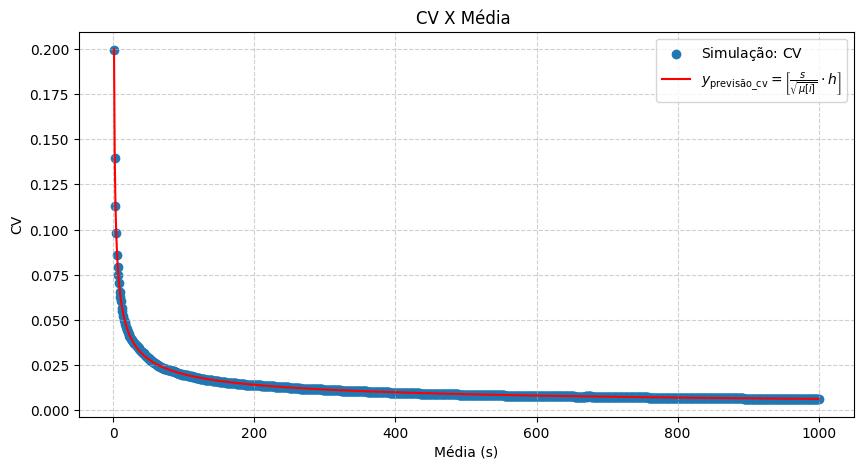

In [ ]:
#Com desvio padrão / média, CV
import matplotlib.pyplot as plt
import numpy as np
import math

cv = []

for i in range(len(mu)):
  cv += [sigma[i] / mu[i]]

#Previsão
y_previsao_cv = []

for i in range(len(mu)):
  y_previsao_cv += [ s / math.sqrt(h * mu[i]) ]

plt.figure(figsize=(10, 5))
plt.scatter(mu, cv, label=r'Simulação: $\text{CV}$')
plt.plot(mu, y_previsao_cv, color='r', label=r'$y_{\text{previsão\_cv}} = \left[ \frac{s}{\sqrt{\mu[i]}} \cdot h \right]$')
plt.xlabel("Média (s)")
plt.ylabel("CV")
plt.title("CV X Média ")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


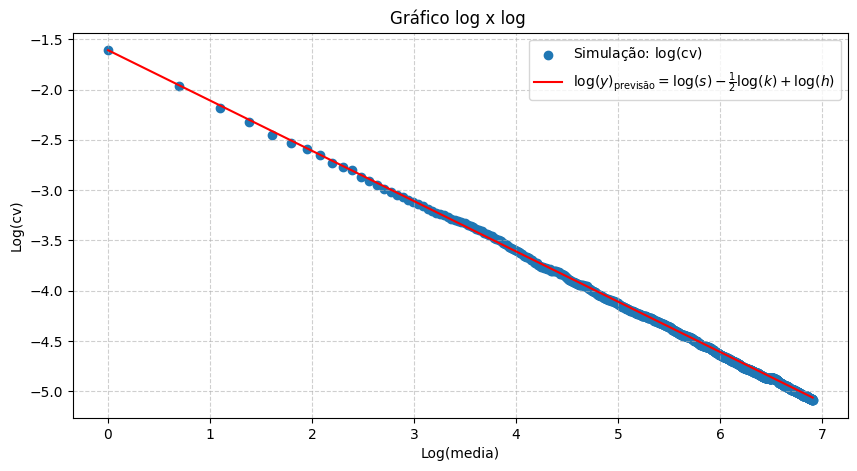

In [ ]:
#Log x log
import matplotlib.pyplot as plt
import numpy as np
import math

logs_cv = []
logs_mu = []
logs_cv += [math.log(i) for i in cv]
logs_mu += [math.log(j) for j in mu]

#Previsão
log_y = []
log_x = []

for indice in range(t):
  k = indice + 1
  log_y += [math.log(s) - (1/2)*math.log(k) - math.log(h)]
  log_x += [logs_mu[indice]]

#Plot
plt.figure(figsize=(10, 5))
plt.scatter(logs_mu, logs_cv, label=r'Simulação: $\log(\text{cv})$')
plt.plot(log_x, log_y, color='r',label=r'$\log(y)_{\text{previsão}} = \log(s) - \frac{1}{2}\log(k) + \log(h)$')
plt.xlabel("Log(media)")
plt.ylabel("Log(cv)")
plt.title("Gráfico log x log ")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

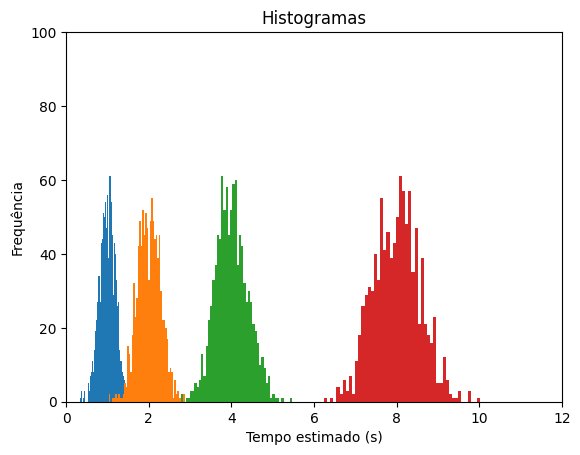

In [ ]:
#Plotar histogramas (na mesma escala)
import matplotlib.pyplot as plt

histogramas = []

#Varia as colunas
for k in range(t):
  estimativas = []

#Varia as linhas
  for l in range(repeticoes):
    estimativas += [matriz[l][k]]
    #print(estimativas)

  histogramas += [estimativas]

#print(histogramas)

#Para t = 1, 2, 4 e 8
for i in (0, 1, 3, 7):
  plt.hist(histogramas[i], bins=50)

plt.xlim(0, 12)
plt.ylim(0, 100)
plt.title('Histogramas')
plt.xlabel("Tempo estimado (s)")
plt.ylabel("Frequência")
#plt.grid(axis='both', alpha=0.5)
plt.show()

